# **Proyecto Final: Estrategia de Trading con Opciones**
## *Simulación de Procesos Financieros*

<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="400" height="600" />

**Estrategia:** Long Straddle sobre QQQ (Invesco QQQ Trust)

**Alumno(s):** Pablo Josué Panécatl García y Paola Andrea Figueroa Álvarez

**Profesor:** Alan Omar Topete

**Fecha:** Abril 2026

---

# Índice de Contenido

1. [Introducción y Justificación](#intro)
2. [Objetivos](#obj)
3. [Marco Teórico](#teoria)
4. [Revisión de Literatura](#revision)
5. [Desarrollo](#desarrollo)
    * 5.1 [Datos del Mercado](#datos)
    * 5.2 [Volatilidad Histórica e Implícita](#vol)
    * 5.3 [Modelo de Black-Scholes](#bs)
    * 5.4 [Payoff Teórico del Straddle](#payoff)
    * 5.5 [Volatility skew/smile](#skew)
    * 5.6 [Griegas del Portafolio](#griegas)
    * 5.7 [Simulación Monte Carlo](#montecarlo)
    * 5.8 [Análisis de sensibilidad](#sens)
6. [Discusión](#discusion)
7. [Conclusiones](#conclusiones)
8. [Bibliografías](#biblio)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False
})

## <a name="intro"></a>1. Introducción y Justificación

El ETF QQQ (Invesco QQQ Trust), al replicar el índice Nasdaq-100, concentra exposición en las principales compañías tecnológicas y de crecimiento a nivel global, lo que lo posiciona como un activo altamente líquido, con un mercado de derivados profundo y una dinámica de precios fuertemente influenciada por factores macroeconómicos, innovación tecnológica y resultados corporativos. Esta naturaleza implica una volatilidad implícita estructuralmente superior a la de índices más diversificados, así como una sensibilidad elevada ante eventos como anuncios de política monetaria, reportes de earnings y disrupciones en sectores clave como inteligencia artificial y semiconductores.

Bajo este contexto, se implementa una estrategia **Long Straddle**, la cual consiste en la compra simultánea de una opción Call y una opción Put at-the-money, con el mismo precio de ejercicio y fecha de vencimiento. Esta estructura elimina la necesidad de anticipar la dirección del movimiento del subyacente, enfocándose en capturar la magnitud del desplazamiento en el precio. La rentabilidad de la estrategia se materializa cuando el activo subyacente experimenta un movimiento suficientemente amplio que exceda el costo total de las primas pagadas.

En el entorno actual (abril de 2026), caracterizado por la temporada de reportes del primer trimestre, incertidumbre respecto a la trayectoria de la política monetaria de la Reserva Federal y tensiones geopolíticas vinculadas a la industria tecnológica, se observa un incremento en la probabilidad de movimientos abruptos en el QQQ. Dado que estos catalizadores pueden detonar variaciones significativas en el precio sin una dirección clara predecible, la implementación de un Long Straddle se justifica como una estrategia eficiente para capitalizar escenarios de alta volatilidad esperada.


## <a name="obj"></a>2. Objetivos
El presente trabajo tiene como objetivo evaluar la viabilidad y rentabilidad esperada de una estrategia de opciones Long Straddle sobre el ETF QQQ (Invesco QQQ Trust), mediante la integración de valuación teórica bajo el modelo de Black-Scholes, análisis del perfil de riesgo a través de las griegas del portafolio, y simulación estocástica mediante el método de Monte Carlo. Específicamente, se busca determinar si las primas de mercado observadas en abril de 2026 reflejan adecuadamente el nivel de volatilidad esperada del subyacente, identificar las condiciones bajo las cuales la estrategia genera rendimientos positivos, y cuantificar su exposición al riesgo en escenarios adversos.

## <a name="teoria"></a>3. Marco Teórico

### Modelo de Black-Scholes (1973)

El precio teórico de una opción europea bajo el modelo de Black-Scholes es:

**Call:**
$$C = S_0 \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

**Put:**
$$P = K \cdot e^{-rT} \cdot N(-d_2) - S_0 \cdot N(-d_1)$$

Donde:
$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2) \cdot T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

- $S_0$: precio spot del subyacente
- $K$: precio de ejercicio (strike)
- $r$: tasa libre de riesgo
- $\sigma$: volatilidad anualizada
- $T$: tiempo al vencimiento (en años)
- $N(\cdot)$: función de distribución acumulada normal estándar

Black-Scholes proporciona el marco de valuación bajo ausencia de arbitraje, permitiendo contrastar precios de mercado con valores teóricos. En un Long Straddle, es fundamental para evaluar si la volatilidad implícita está sobre o subestimada, ya que la rentabilidad depende directamente de pagar primas “baratas” relativo al movimiento esperado.

### Griegas

| Griega | Significado |
|--------|-------------|
| **Delta (Δ)** | Sensibilidad del precio de la opción ante cambios en $S$ |
| **Gamma (Γ)** | Tasa de cambio de Delta; curvatura |
| **Theta (Θ)** | Decaimiento temporal (pérdida de valor por día) |
| **Vega (ν)** | Sensibilidad ante cambios en volatilidad implícita |
| **Rho (ρ)** | Sensibilidad ante cambios en la tasa de interés |

Las griegas permiten entender la exposición al riesgo de la estrategia en tiempo real. En un Long Straddle, la posición inicia delta-neutral, con gamma y vega positivos (beneficia de movimientos bruscos y aumentos de volatilidad), pero con theta negativo, lo que implica que el tiempo juega en contra si el movimiento no ocurre como se espera.

### Simulación Monte Carlo

Se simula la trayectoria del precio bajo movimiento Browniano Geométrico:
$$S_t = S_0 \cdot \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma\sqrt{t}\,Z\right], \quad Z \sim N(0,1)$$

El payoff esperado se descuenta a valor presente para obtener el precio simulado.

La simulación Monte Carlo permite modelar múltiples trayectorias posibles del subyacente bajo incertidumbre. Para un Long Straddle, es clave para estimar la probabilidad de alcanzar los puntos de equilibrio, analizar la distribución de rendimientos y validar si la volatilidad esperada compensa el costo inicial de la estrategia.

## <a name="revision"></a>4. Revisión de literatura

La valuación de opciones sobre activos financieros tiene su fundamento en el trabajo seminal de Black y Scholes (1973), quienes derivaron una fórmula cerrada para el precio de opciones europeas bajo supuestos de mercado completo, ausencia de arbitraje y volatilidad constante. Este modelo revolucionó la industria de derivados y sigue siendo el punto de referencia estándar en la práctica, si bien su supuesto de volatilidad constante ha sido ampliamente cuestionado por la evidencia empírica. Rubinstein (1994) documentó que, tras el crash bursátil de 1987, los mercados de opciones sobre índices de renta variable comenzaron a exhibir de forma sistemática un patrón de volatilidad implícita decreciente con el strike, conocido como volatility skew, que contradice directamente las predicciones del modelo de Black-Scholes. Este hallazgo ha motivado décadas de investigación orientadas a modelos de volatilidad estocástica, como el de Heston (1993), que introducen una segunda fuente de aleatoriedad para capturar la dinámica observada en los mercados reales.
En paralelo, el uso de simulación Monte Carlo en la valuación de derivados fue introducido por Boyle (1977) en un artículo que demostró cómo modelar trayectorias de precios bajo Movimiento Browniano Geométrico para estimar el valor esperado de los payoffs descontados. Esta aproximación generó miles de trayectorias posibles del subyacente y promedió los payoffs resultantes, sentando las bases del método que se emplea en este proyecto. Boyle, Broadie y Glasserman (1997) extendieron posteriormente este enfoque a derivados más complejos e introdujeron técnicas de reducción de varianza para mejorar la eficiencia computacional, estableciendo Monte Carlo como la herramienta de valuación estándar para instrumentos con payoffs no lineales o dependientes de trayectoria. Wikipedia
Respecto a las estrategias de volatilidad, la literatura financiera identifica el Long Straddle como una posición neutral en dirección, cuya rentabilidad depende exclusivamente de la magnitud del movimiento del subyacente. Trabajos recientes han demostrado el desempeño destacado del straddle en mercados de alta volatilidad, señalando que la estrategia puede cubrir riesgos eficazmente y ofrecer rendimientos elevados cuando se producen movimientos de precio extremos. El presente trabajo se diferencia de estos estudios al aplicar el análisis sobre datos de mercado en tiempo real del ETF QQQ en un contexto macroeconómico específico, incorporando el volatility skew observado, el análisis completo de griegas y métricas de riesgo derivadas de la simulación, elementos que los estudios generales sobre straddles raramente combinan en un solo ejercicio cuantitativo integrado.

## 5. Desarrollo

El desarrollo del proyecto sigue un flujo metodológico de ocho etapas que va desde la recopilación de datos hasta el análisis de sensibilidad. Se parte de la obtención en tiempo real de la cadena de opciones sobre QQQ mediante yfinance, extrayendo el precio spot, el strike at-the-money y los precios de mercado de la call y put seleccionadas como midpoint bid-ask. Con ello, se calcula la volatilidad histórica en tres ventanas temporales: 21, 63 y 252 días, lo que sirve como insumo clave en la valuación con Black–Scholes. Este modelo actúa como referencia sin arbitraje para estimar precios teóricos, el costo del straddle y sus puntos de equilibrio. Dado que sus supuestos simplifican la realidad, la comparación entre el precio teórico y el de mercado permite identificar primas de riesgo adicionales que el modelo no incorpora.
Para profundizar en esa brecha, se estima la volatilidad implícita de cada strike disponible en la cadena y se construye el volatility smile, revelando cómo el mercado valora el riesgo de forma asimétrica entre puts y calls. Asimismo, se calculan las griegas del portafolio para cuantificar la exposición al riesgo en tiempo real y entender la lógica operativa de la posición: cuánto se pierde por el paso del tiempo, cuánto se gana con movimientos bruscos y cuánto con aumentos de volatilidad implícita. Finalmente, se complementa el análisis determinístico de Black-Scholes con una simulación Monte Carlo de 50,000 trayectorias, lo que permite construir la distribución completa de resultados posibles al vencimiento junto con sus probabilidades de pérdida y un análisis de sensibilidad para evaluar cómo responde el valor del straddle ante cambios en volatilidad y tiempo restante.

### <a name="datos"></a>5.1 Datos del Mercado

In [2]:
# Datos
TICKER= 'QQQ'
PERIODO_HIST= '1y'          # 1 año de historia para vol. histórica
T_DIAS= 30                # Días al vencimiento
T= T_DIAS / 252      # En años (días hábiles en los que cotiza la bolsa)
r= 0.0441            # Tasa libre de riesgo (actualizado en abril 2026)

qqq = yf.Ticker(TICKER)
fecha_venc = "2026-05-29"
chain = qqq.option_chain(fecha_venc)
calls = chain.calls
puts  = chain.puts
S0 = float(qqq.history(period='1d')['Close'].iloc[-1])

# Filtrar la opción ATM (strike más cercano a S0)
call_atm = calls.iloc[(calls['strike'] - S0).abs().argsort()[:1]]
put_atm  = puts.iloc[(puts['strike']   - S0).abs().argsort()[:1]]

# Precio de mercado = midpoint entre bid y ask
C0 = (call_atm['bid'].values[0] + call_atm['ask'].values[0]) / 2
P0 = (put_atm['bid'].values[0]  + put_atm['ask'].values[0])  / 2
K  = call_atm['strike'].values[0]

print(f"Ticker      : {TICKER}")
print(f"Precio Spot : ${S0:.2f}")
print(f"Strike (K)  : ${K:.2f}")
print(f"Vencimiento : {T_DIAS} días hábiles ({T:.4f} años)")
print(f"Tasa libre  : {r*100:.2f}%")

Ticker      : QQQ
Precio Spot : $667.74
Strike (K)  : $668.00
Vencimiento : 30 días hábiles (0.1190 años)
Tasa libre  : 4.41%


El hecho de que el strike se encuentre prácticamente al nivel del precio spot (posición at-the-money) maximiza la sensibilidad del straddle ante movimientos del subyacente. Sin embargo, como el tiempo hasta el vencimiento es corto, la opción pierde valor rápidamente con el paso de los días. Esto significa que el precio del activo debe moverse pronto; si no lo hace, la estrategia empieza a perder dinero. Por su parte, la tasa libre de riesgo (4.41%)  nos ayudará a evaluar el desempeño de la estrategia, es decir, la volatilidad, pues la estrategia solo funciona si el precio del activo se mueve más de lo que el mercado esperaba cuando se pagaron las primas.

### <a name="vol"></a>5.2 Volatilidad Histórica e Implícita

Volatilidad Histórica (21 días)  : 15.12%
Volatilidad Histórica (63 días)  : 19.76%
Volatilidad Histórica (1 año)    : 16.27%


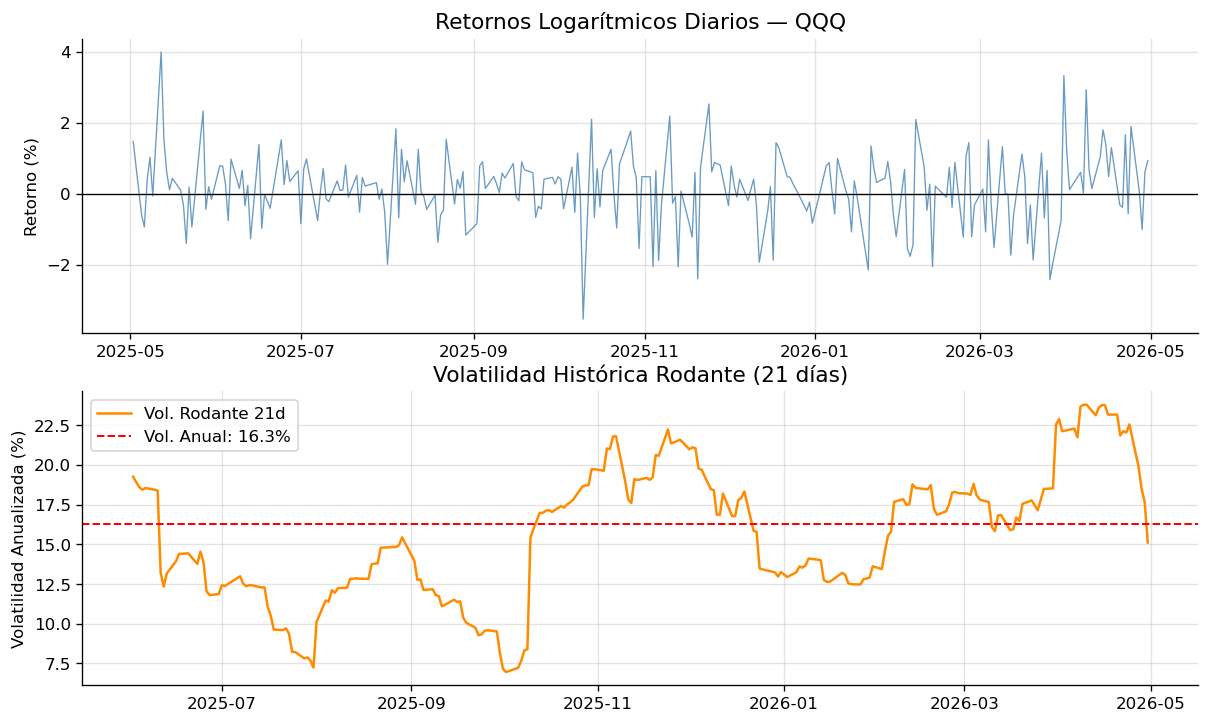

In [3]:
# Volatilidad Histórica
hist = yf.download(TICKER, period=PERIODO_HIST, auto_adjust=True, progress=False)
precios = hist['Close'].dropna()
log_ret = np.log(precios / precios.shift(1)).dropna()

# Volatilidad histórica anualizada (ventanas de 21 y 63 días)
vol_21d  = log_ret.rolling(21).std().iloc[-1]  * np.sqrt(252)
vol_63d  = log_ret.rolling(63).std().iloc[-1]  * np.sqrt(252)
vol_hist = log_ret.std() * np.sqrt(252)         # Todo el período

print(f"Volatilidad Histórica (21 días)  : {float(vol_21d)*100:.2f}%")
print(f"Volatilidad Histórica (63 días)  : {float(vol_63d)*100:.2f}%")
print(f"Volatilidad Histórica (1 año)    : {float(vol_hist)*100:.2f}%")

sigma = float(vol_hist)   # Usamos vol. anual completa como insumo base

# Gráficas
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(log_ret.index, log_ret.values * 100, color='steelblue', lw=0.8, alpha=0.8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title(f'Retornos Logarítmicos Diarios — {TICKER}', fontsize=13)
axes[0].set_ylabel('Retorno (%)')

vol_rol = log_ret.rolling(21).std() * np.sqrt(252) * 100
axes[1].plot(vol_rol.index, vol_rol.values, color='darkorange', lw=1.5, label='Vol. Rodante 21d')
axes[1].axhline(float(vol_hist)*100, color='red', linestyle='--', lw=1.2, label=f'Vol. Anual: {float(vol_hist)*100:.1f}%')
axes[1].set_title('Volatilidad Histórica Rodante (21 días)', fontsize=13)
axes[1].set_ylabel('Volatilidad Anualizada (%)')
axes[1].legend()

La volatilidad histórica de 21 días (15.12%) se encuentra ligeramente por debajo de la de 1 año (16.27%), lo que sugiere que en el muy corto plazo el mercado ha estado relativamente más estable y con movimientos menos extremos. Sin embargo, la volatilidad de 63 días (19.76%) es considerablemente mayor, lo que indica que en un horizonte reciente han existido episodios de mayor incertidumbre y cambios más bruscos en el precio. Esta diferencia entre ventanas de tiempo refleja que la volatilidad no es constante, sino que tiende a agruparse en periodos donde aumenta rápidamente. En conjunto, esto sugiere un entorno donde la volatilidad puede repuntar nuevamente, lo cual es favorable para un Long Straddle, ya que incrementa la probabilidad de que el precio se desplace lo suficiente en cualquier dirección para superar el costo de las primas pagadas.

### <a name="vol"></a>5.3 Modelo de Black-Scholes

In [4]:
# Modelo de Black Scholes

def bs_d1d2(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call(S, K, r, sigma, T):
    d1, d2 = bs_d1d2(S, K, r, sigma, T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, r, sigma, T):
    d1, d2 = bs_d1d2(S, K, r, sigma, T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_straddle(S, K, r, sigma, T):
    return bs_call(S, K, r, sigma, T) + bs_put(S, K, r, sigma, T)

# Precios TEÓRICOS (para comparar)
C0_bs = bs_call(S0, K, r, sigma, T)
P0_bs = bs_put(S0, K, r, sigma, T)

costo_total = C0 + P0   

# Puntos de equilibrio (breakeven)
BE_inf = K - costo_total
BE_sup = K + costo_total

print(f"\n{'─'*45}")
print(f"  PRECIOS BLACK-SCHOLES — Long Straddle")
print(f"{'─'*45}")
print(f"  Prima Call — Mercado : ${C0:.4f}   BS: ${C0_bs:.4f}")
print(f"  Prima Put  — Mercado : ${P0:.4f}   BS: ${P0_bs:.4f}")
print(f"  Costo Total (C₀+P₀) : ${costo_total:.4f}")
print(f"{'─'*45}")
print(f"  Breakeven Inferior  : ${BE_inf:.4f}")
print(f"  Strike (K)          : ${K:.2f}")
print(f"  Breakeven Superior  : ${BE_sup:.4f}")
print(f"  Pérdida Máxima      : -${costo_total:.4f}  (si S_T = K)")
print(f"  Ganancia            : Ilimitada")
print(f"{'─'*45}")


─────────────────────────────────────────────
  PRECIOS BLACK-SCHOLES — Long Straddle
─────────────────────────────────────────────
  Prima Call — Mercado : $15.4500   BS: $16.5875
  Prima Put  — Mercado : $13.5800   BS: $13.3497
  Costo Total (C₀+P₀) : $29.0300
─────────────────────────────────────────────
  Breakeven Inferior  : $638.9700
  Strike (K)          : $668.00
  Breakeven Superior  : $697.0300
  Pérdida Máxima      : -$29.0300  (si S_T = K)
  Ganancia            : Ilimitada
─────────────────────────────────────────────


Las primas de mercado están cercanas a las estimadas por Black–Scholes, con una ligera subvaluación en la call y una put prácticamente al mismo nivel, lo que sugiere que el costo total del straddle es razonable respecto al valor teórico. Los puntos de equilibrio en $638.97 y $697.03 implican que se requiere un movimiento de más o menos 4.4% (29.03/668), desde el strike para ser rentable al vencimiento. La pérdida máxima queda acotada al costo pagado si el precio termina en K, mientras que el potencial de ganancia es abierto; por tanto, la idea principal es que esta estrategia solo funciona si el precio se mueve más de lo que el mercado esperaba, es decir, si hay más movimiento del previsto.

### <a name="payoff"></a>5.4 Payoff Teórico del Straddle

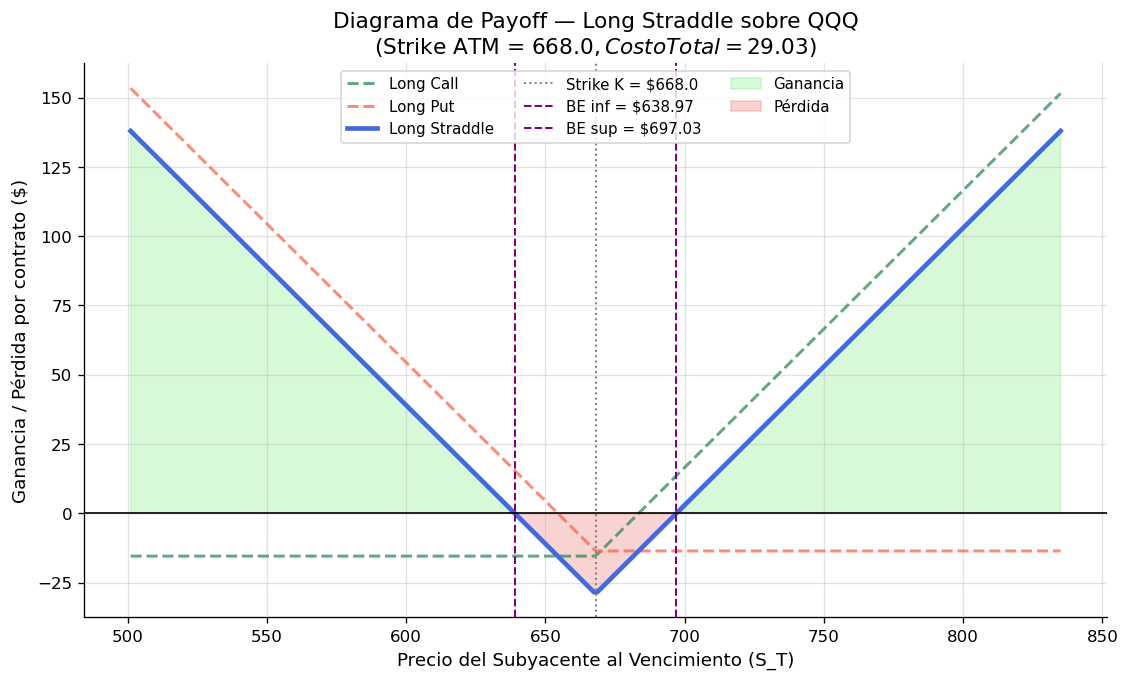

In [5]:
# Payoff al vencimiento
ST = np.linspace(K * 0.75, K * 1.25, 300)

payoff_call     = np.maximum(ST - K, 0) - C0
payoff_put      = np.maximum(K - ST, 0) - P0
payoff_straddle = payoff_call + payoff_put

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(ST, payoff_call,     '--', color='seagreen',  lw=1.8, alpha=0.75, label='Long Call')
ax.plot(ST, payoff_put,      '--', color='tomato',    lw=1.8, alpha=0.75, label='Long Put')
ax.plot(ST, payoff_straddle, '-',  color='royalblue', lw=2.8, label='Long Straddle')

ax.axhline(0, color='black', lw=1)
ax.axvline(K,        color='gray',   lw=1.2, linestyle=':', label=f'Strike K = ${K}')
ax.axvline(BE_inf,   color='purple', lw=1.2, linestyle='--', label=f'BE inf = ${BE_inf:.2f}')
ax.axvline(BE_sup,   color='purple', lw=1.2, linestyle='--', label=f'BE sup = ${BE_sup:.2f}')

ax.fill_between(ST, payoff_straddle, 0,where=payoff_straddle > 0, color='lightgreen', alpha=0.35, label='Ganancia')
ax.fill_between(ST, payoff_straddle, 0, where=payoff_straddle < 0, color='lightcoral', alpha=0.35, label='Pérdida')

ax.set_title(f'Diagrama de Payoff — Long Straddle sobre {TICKER}\n(Strike ATM = ${K}, Costo Total = ${costo_total:.2f})', fontsize=13)
ax.set_xlabel('Precio del Subyacente al Vencimiento (S_T)', fontsize=11)
ax.set_ylabel('Ganancia / Pérdida por contrato ($)', fontsize=11)
ax.legend(loc='upper center', ncol=3, fontsize=9)

El diagrama muestra una estructura en “V”, donde la pérdida máxima ocurre en el strike ($668) y está limitada al costo total pagado ($29.03). Esto significa que desde el inicio sabes cuánto es lo máximo que puedes perder, lo cual es una ventaja importante de esta estrategia. A partir de los puntos de equilibrio ($638.97 y $697.03), la posición comienza a generar ganancias en cualquier dirección, lo que confirma que la estrategia no depende de acertar la dirección del mercado, sino de que el movimiento sea suficientemente grande. Mientras más se aleje el precio del strike, mayor será la ganancia obtenida. En términos prácticos, si el precio se mantiene cerca del strike al vencimiento, se pierde dinero; pero si se aleja con fuerza hacia arriba o hacia abajo, la ganancia crece sin límite, aprovechando movimientos extremos del mercado.

### <a name="skew"></a>5.5 Volatility skew/smile

--- Volatilidad Implícita (Ticker: QQQ | Vencimiento: 2026-05-29) ---


,Strike,Tipo,Mid,IV (%)
0,435.0,Put OTM,0.100,47.002126
1,440.0,Put OTM,0.110,46.321122
2,445.0,Put OTM,0.120,45.603120
3,450.0,Put OTM,0.130,44.854093
4,455.0,Put OTM,0.145,44.250667
...,...,...,...,...
170,735.0,Call OTM,0.290,13.303983
171,740.0,Call OTM,0.220,13.544427
172,745.0,Call OTM,0.180,13.924620
173,750.0,Call OTM,0.145,14.258312


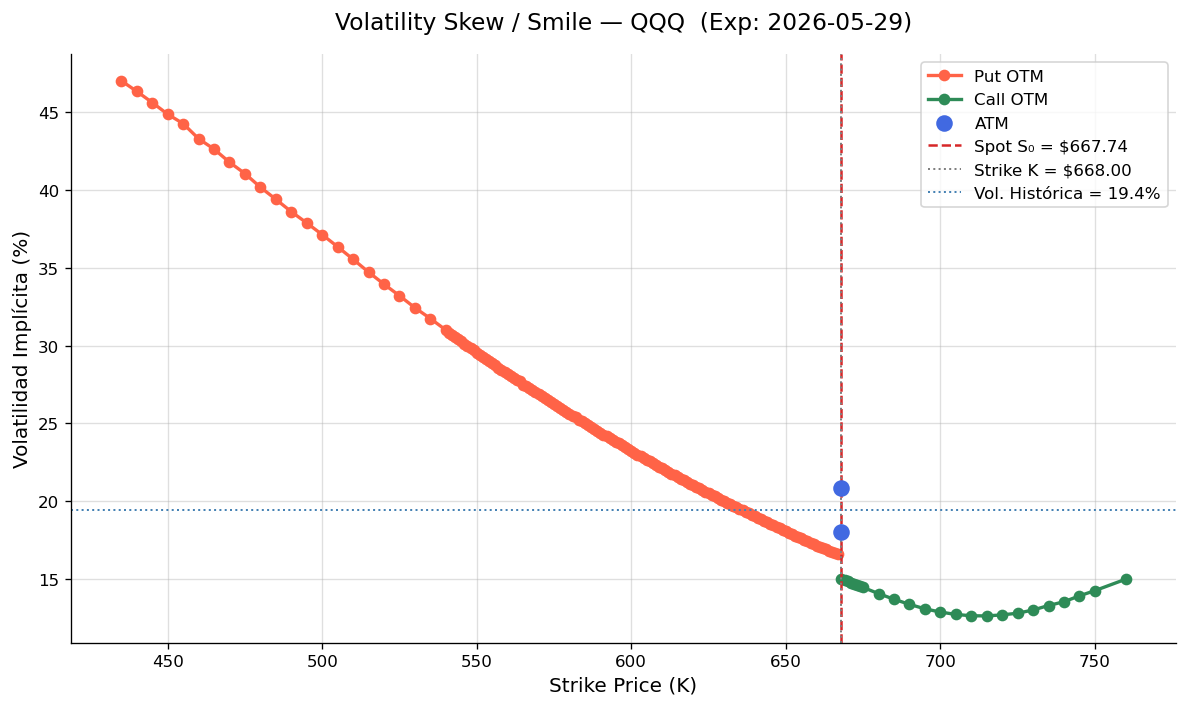

In [6]:
# Volatilidad Implícita 
from scipy.optimize import brentq, newton

def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol_robust(price_mkt, S, K, r, T, tipo="call", tol=1e-8, maxiter=100):
    """IV con Brent + fallback a Newton, igual que el código de clase."""
    if tipo == "call":
        lower = max(0.0, S - K*np.exp(-r*T))
        upper = S
    else:
        lower = max(0.0, K*np.exp(-r*T) - S)
        upper = K*np.exp(-r*T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        return np.nan  # fuera de rango teórico

    def f(sig):
        return bs_price(sig) - price_mkt  # función objetivo

    precio_fn = bs_call if tipo == "call" else bs_put

    def f(sig):
        return precio_fn(S, K, r, sig, T) - price_mkt

    # Brent con ajuste dinámico del extremo superior
    a, b = 1e-6, 5.0
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            if f(a) * f(b_try) <= 0:
                b = b_try
                break

    try:
        return brentq(f, a, b, xtol=tol, maxiter=maxiter)
    except Exception:
        pass

    # Fallback: Newton-Raphson
    seed = min(max(float(vol_hist) if np.isfinite(float(vol_hist)) else 0.2, 1e-3), 2.0)
    try:
        iv = newton(f, seed, fprime=lambda s: bs_vega(S, K, r, T, s), tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    return np.nan  # no convergió

#  Calcular IV para puts OTM y calls OTM 
registros = []

# Puts OTM (strike < S0)
for _, row in puts.iterrows():
    ki  = row['strike']
    mid = (row['bid'] + row['ask']) / 2.0
    if ki >= S0 or mid < 0.10:
        continue
    iv = implied_vol_robust(mid, S0, ki, r, T, tipo="put")
    if not np.isnan(iv) and 0.01 < iv < 2.0:
        registros.append({'Strike': ki, 'Tipo': 'Put OTM', 'Mid': mid, 'IV (%)': iv * 100})

# Calls OTM (strike > S0)
for _, row in calls.iterrows():
    ki  = row['strike']
    mid = (row['bid'] + row['ask']) / 2.0
    if ki <= S0 or mid < 0.10:
        continue
    iv = implied_vol_robust(mid, S0, ki, r, T, tipo="call")
    if not np.isnan(iv) and 0.01 < iv < 2.0:
        registros.append({'Strike': ki, 'Tipo': 'Call OTM', 'Mid': mid, 'IV (%)': iv * 100})

IV_call = call_atm['impliedVolatility'].values[0]
IV_put  = put_atm['impliedVolatility'].values[0]
sigma   = (IV_call + IV_put) / 2   # IV ATM promedio como vol base forward-looking

# ATM (la call y put que ya usamos)
registros.append({'Strike': K, 'Tipo': 'Call ATM', 'Mid': C0, 'IV (%)': IV_call * 100})
registros.append({'Strike': K, 'Tipo': 'Put ATM',  'Mid': P0, 'IV (%)': IV_put  * 100})

df_iv = pd.DataFrame(registros).sort_values('Strike').dropna().reset_index(drop=True)

print(f"--- Volatilidad Implícita (Ticker: {TICKER} | Vencimiento: {fecha_venc}) ---")
display(df_iv)

# Gráfica Smile/Skew 
calls_iv = df_iv[df_iv['Tipo'] == 'Call OTM']
puts_iv  = df_iv[df_iv['Tipo'] == 'Put OTM']
atm_iv   = df_iv[df_iv['Tipo'].str.contains('ATM')]

plt.figure(figsize=(10, 6))
plt.plot(puts_iv['Strike'],  puts_iv['IV (%)'],  'o-', color='tomato',    lw=2, ms=6, label='Put OTM')
plt.plot(calls_iv['Strike'], calls_iv['IV (%)'], 'o-', color='seagreen',  lw=2, ms=6, label='Call OTM')
plt.scatter(atm_iv['Strike'], atm_iv['IV (%)'],  color='royalblue', zorder=5, s=80, label='ATM')
plt.axvline(S0,    color='#d62728', linestyle='--', lw=1.5, label=f'Spot S₀ = ${S0:.2f}')
plt.axvline(K,     color='gray',    linestyle=':',  lw=1.2, label=f'Strike K = ${K:.2f}')
plt.axhline(sigma*100, color='steelblue', linestyle=':', lw=1.2, label=f'Vol. Histórica = {sigma*100:.1f}%')
plt.title(f'Volatility Skew / Smile — {TICKER}  (Exp: {fecha_venc})', fontsize=14, pad=15)
plt.xlabel('Strike Price (K)', fontsize=12)
plt.ylabel('Volatilidad Implícita (%)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

La gráfica muestra un claro skew de volatilidad: las puts fuera del dinero (OTM) tienen volatilidades implícitas mucho más altas que las calls OTM, lo que indica que el mercado paga más por protección ante caídas que por apuestas alcistas. En la zona at-the-money (cerca del strike $668), la volatilidad se encuentra alrededor de 18%–21%, ligeramente por encima de la volatilidad histórica (~19.4%), lo que sugiere una prima por incertidumbre esperada.

El “brinco” entre la curva de puts y la de calls significa que las puts suelen ser más caras, ya que más personas las compran para protegerse si el precio baja; el mercado cree que es más probable o más riesgoso que el precio caiga fuerte a que suba de la misma forma.
En conjunto, esto implica que el lado de la put está relativamente más caro que el de la call, lo cual es relevante para un Long Straddle, ya que parte del costo elevado proviene de esa protección contra caídas. Sin embargo, también confirma que el mercado espera posibles movimientos fuertes, especialmente a la baja, reforzando la hipótesis de alta volatilidad implícita.

### <a name="griegas"></a>5.6 Griegas del Portafolio


───────────────────────────────────────────────────────
  GRIEGAS DEL LONG STRADDLE (por contrato, S₀=$667.74)
───────────────────────────────────────────────────────
  Delta  (Δ) : +0.084440  ← ~neutro; |Δ_call|≈|Δ_put|
  Gamma  (Γ) : +0.017725  ← positivo; gana cuando S se mueve
  Theta  (Θ) : -0.595520  ← negativo; pierde valor cada día
  Vega   (ν) : +1.827960  ← positivo; gana con ↑ volatilidad
  Rho    (ρ) : +0.024606  ← casi neutro a T corto
───────────────────────────────────────────────────────

  Interpretación clave:
  • Theta = $-59.5520/día por cada $100 de nominal
  • Vega  = $1.8280 por cada +1% de vol. implícita


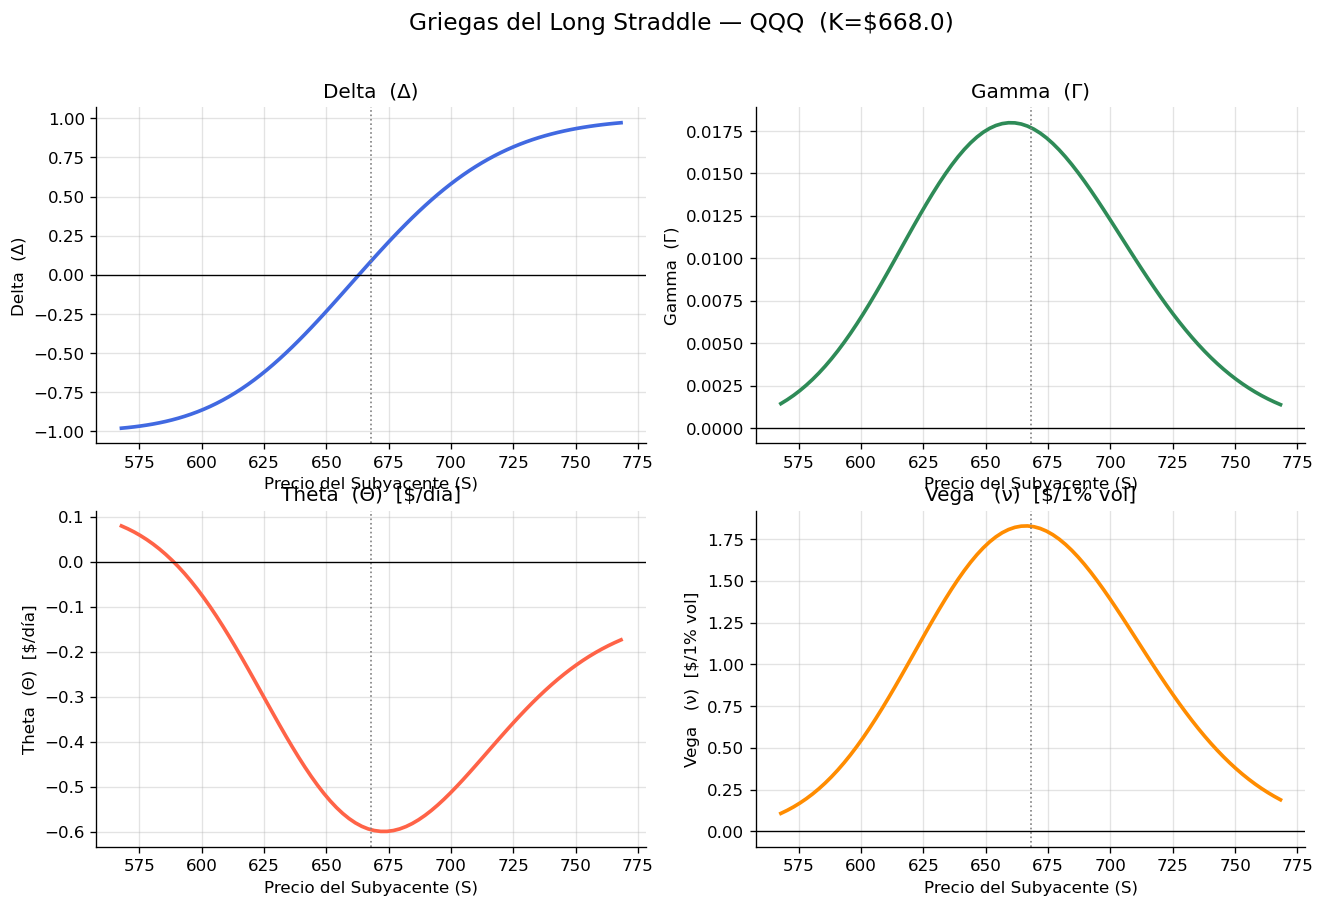

In [7]:
# Griegas

def greeks(S, K, r, sigma, T):
    d1, d2 = bs_d1d2(S, K, r, sigma, T)
    delta_call =  norm.cdf(d1)
    delta_put  = -norm.cdf(-d1)
    gamma      =  norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta_call = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                  - r * K * np.exp(-r*T) * norm.cdf(d2)) / 252
    theta_put  = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                  + r * K * np.exp(-r*T) * norm.cdf(-d2)) / 252
    vega       = S * norm.pdf(d1) * np.sqrt(T) / 100  # por 1% de vol
    rho_call   =  K * T * np.exp(-r*T) * norm.cdf(d2)  / 100
    rho_put    = -K * T * np.exp(-r*T) * norm.cdf(-d2) / 100
    return {
        'delta_call': delta_call, 'delta_put': delta_put,
        'gamma': gamma,
        'theta_call': theta_call, 'theta_put': theta_put,
        'vega': vega,
        'rho_call': rho_call, 'rho_put': rho_put
    }

g = greeks(S0, K, r, sigma, T)

# Griegas del Straddle = suma de las patas
delta_st = g['delta_call'] + g['delta_put']
gamma_st = 2 * g['gamma']
theta_st = g['theta_call'] + g['theta_put']
vega_st  = 2 * g['vega']
rho_st   = g['rho_call'] + g['rho_put']

print(f"\n{'─'*55}")
print(f"  GRIEGAS DEL LONG STRADDLE (por contrato, S₀=${S0:.2f})")
print(f"{'─'*55}")
print(f"  Delta  (Δ) : {delta_st:+.6f}  ← ~neutro; |Δ_call|≈|Δ_put|")
print(f"  Gamma  (Γ) : {gamma_st:+.6f}  ← positivo; gana cuando S se mueve")
print(f"  Theta  (Θ) : {theta_st:+.6f}  ← negativo; pierde valor cada día")
print(f"  Vega   (ν) : {vega_st:+.6f}  ← positivo; gana con ↑ volatilidad")
print(f"  Rho    (ρ) : {rho_st:+.6f}  ← casi neutro a T corto")
print(f"{'─'*55}")
print(f"\n  Interpretación clave:")
print(f"  • Theta = ${theta_st*100:.4f}/día por cada $100 de nominal")
print(f"  • Vega  = ${vega_st:.4f} por cada +1% de vol. implícita")

# Sensibilidad de griegas ante cambios en precio
spot_range = np.linspace(K * 0.85, K * 1.15, 80)
deltas, gammas, thetas, vegas = [], [], [], []

for s in spot_range:
    g_tmp = greeks(s, K, r, sigma, T)
    deltas.append(g_tmp['delta_call'] + g_tmp['delta_put'])
    gammas.append(2 * g_tmp['gamma'])
    thetas.append(g_tmp['theta_call'] + g_tmp['theta_put'])
    vegas.append(2 * g_tmp['vega'])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f'Griegas del Long Straddle — {TICKER}  (K=${K})', fontsize=14)

pairs = [
    (axes[0,0], deltas, 'Delta  (Δ)', 'royalblue'),
    (axes[0,1], gammas, 'Gamma  (Γ)', 'seagreen'),
    (axes[1,0], thetas, 'Theta  (Θ)  [$/día]', 'tomato'),
    (axes[1,1], vegas,  'Vega   (ν)  [$/1% vol]', 'darkorange'),
]
for ax, vals, label, color in pairs:
    ax.plot(spot_range, vals, color=color, lw=2.2)
    ax.axvline(K,  color='gray', lw=1, linestyle=':')
    ax.axhline(0,  color='black', lw=0.8)
    ax.set_xlabel('Precio del Subyacente (S)')
    ax.set_ylabel(label)
    ax.set_title(label)

Las griegas muestran cómo se comporta esta estrategia en la práctica. La Delta cercana a cero indica que la posición inicia casi neutral en dirección, ya que la call y la put se compensan. Sin embargo, el Gamma positivo hace que esa Delta cambie rápidamente cuando el precio del subyacente se mueve, por lo que la posición empieza a capturar ganancias ante movimientos fuertes. El principal costo es el Theta negativo, que refleja el decaimiento temporal: la estrategia pierde valor con el paso de los días si no hay un movimiento relevante (≈ $59.55 diarios por cada $100 de inversión). Por otro lado, el Vega positivo muestra que la posición es sensible a la volatilidad implícita; si esta aumenta en 1%, el valor del straddle sube aproximadamente $1.83. Finalmente, Rho casi no afecta en este caso, ya que los cambios en tasas de interés tienen muy poco impacto en la estrategia en el corto plazo. En conjunto, el desempeño depende de que haya movimientos importantes en el precio o aumentos en la volatilidad, mientras que el paso del tiempo juega en contra si el mercado se mantiene estable.

### <a name="montecarlo"></a>5.7 Simulación Monte Carlo

In [8]:
# Simulación de Monte Carlo
np.random.seed(42)

N_SIM  = 50_000   
N_DIAS = T_DIAS  
dt     = 1/252    

mu = float(log_ret.mean()) * 252   

# Simular trayectorias: S_t via MBG
Z    = np.random.standard_normal((N_DIAS, N_SIM))
log_S = (np.log(S0) +
         np.cumsum((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z, axis=0))
trayectorias = np.exp(log_S)       

ST_sim = trayectorias[-1, :]       # Precios finales

# Payoff simulado del Straddle
payoff_sim_call = np.maximum(ST_sim - K, 0)
payoff_sim_put  = np.maximum(K - ST_sim, 0)
payoff_sim      = payoff_sim_call + payoff_sim_put - costo_total   

# Métricas
precio_mc   = np.exp(-r * T) * np.mean(payoff_sim + costo_total)
ganancia_esp = np.mean(payoff_sim)
prob_profit  = np.mean(payoff_sim > 0) * 100
VaR_95      = np.percentile(payoff_sim, 5)
CVaR_95     = payoff_sim[payoff_sim <= VaR_95].mean()

print(f"\n{'─'*55}")
print(f"  RESULTADOS MONTE CARLO  ({N_SIM:,} simulaciones)")
print(f"{'─'*55}")
print(f"  Precio MC descontado    : ${precio_mc:.4f}  (BS: ${costo_total:.4f})")
print(f"  Ganancia/Pérdida esp.   : ${ganancia_esp:.4f}")
print(f"  Probabilidad de ganancia: {prob_profit:.1f}%")
print(f"  VaR 95% (peor 5%)       : ${VaR_95:.4f}")
print(f"  CVaR 95% (expected loss): ${CVaR_95:.4f}")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
  RESULTADOS MONTE CARLO  (50,000 simulaciones)
───────────────────────────────────────────────────────
  Precio MC descontado    : $42.1291  (BS: $29.0300)
  Ganancia/Pérdida esp.   : $13.3209
  Probabilidad de ganancia: 57.9%
  VaR 95% (peor 5%)       : $-25.8305
  CVaR 95% (expected loss): $-27.4275
───────────────────────────────────────────────────────


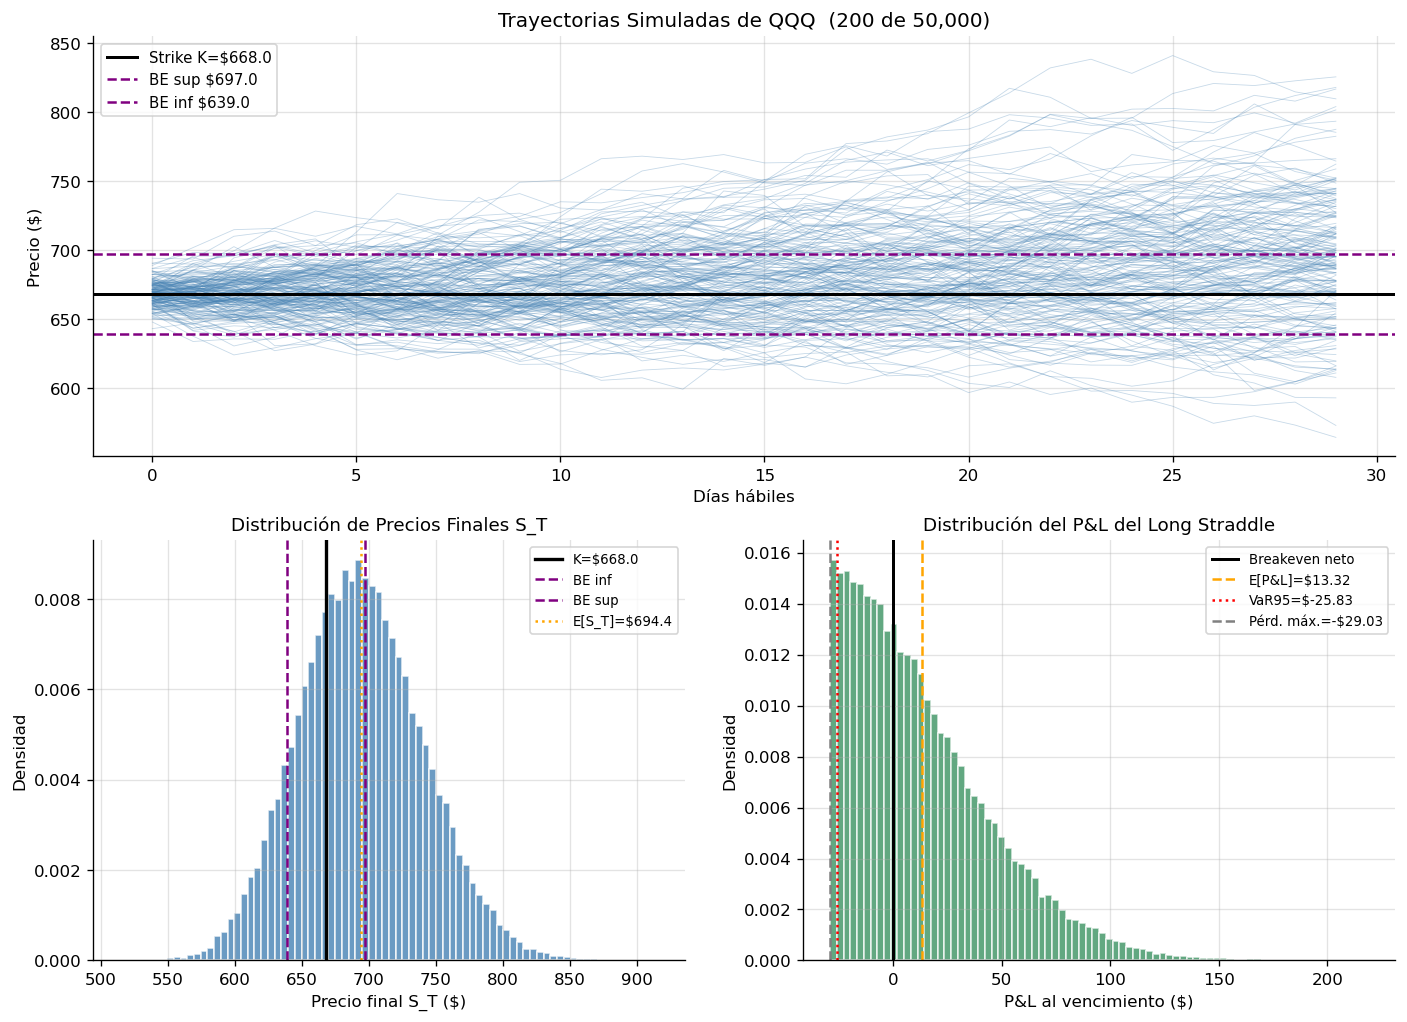

In [9]:
# Visualización Monte Carlo
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# 1) Trayectorias (muestra de 200)
ax1 = fig.add_subplot(gs[0, :])
muestra = np.random.choice(N_SIM, 200, replace=False)
for i in muestra:
    ax1.plot(trayectorias[:, i], lw=0.5, alpha=0.3, color='steelblue')
ax1.axhline(K,      color='black',  lw=1.8, linestyle='-',  label=f'Strike K=${K}')
ax1.axhline(BE_sup, color='purple', lw=1.5, linestyle='--', label=f'BE sup ${BE_sup:.1f}')
ax1.axhline(BE_inf, color='purple', lw=1.5, linestyle='--', label=f'BE inf ${BE_inf:.1f}')
ax1.set_title(f'Trayectorias Simuladas de {TICKER}  (200 de {N_SIM:,})', fontsize=12)
ax1.set_xlabel('Días hábiles')
ax1.set_ylabel('Precio ($)')
ax1.legend(loc='upper left', fontsize=9)

# 2) Distribución de precios finales
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ST_sim, bins=80, color='steelblue', edgecolor='white', alpha=0.8, density=True)
ax2.axvline(K,      color='black',  lw=2,   linestyle='-',  label=f'K=${K}')
ax2.axvline(BE_inf, color='purple', lw=1.5, linestyle='--', label=f'BE inf')
ax2.axvline(BE_sup, color='purple', lw=1.5, linestyle='--', label=f'BE sup')
ax2.axvline(np.mean(ST_sim), color='orange', lw=1.5, linestyle=':', label=f'E[S_T]=${np.mean(ST_sim):.1f}')
ax2.set_title('Distribución de Precios Finales S_T', fontsize=11)
ax2.set_xlabel('Precio final S_T ($)')
ax2.set_ylabel('Densidad')
ax2.legend(fontsize=8)

# 3) Distribución de P&L del Straddle
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(payoff_sim, bins=80, color='seagreen', edgecolor='white', alpha=0.75, density=True)
ax3.axvline(0,              color='black',  lw=1.8, linestyle='-',  label='Breakeven neto')
ax3.axvline(ganancia_esp,   color='orange', lw=1.5, linestyle='--', label=f'E[P&L]=${ganancia_esp:.2f}')
ax3.axvline(VaR_95,         color='red',    lw=1.5, linestyle=':',  label=f'VaR95=${VaR_95:.2f}')
ax3.axvline(-costo_total,   color='gray',   lw=1.5, linestyle='--', label=f'Pérd. máx.=-${costo_total:.2f}')
ax3.set_title('Distribución del P&L del Long Straddle', fontsize=11)
ax3.set_xlabel('P&L al vencimiento ($)')
ax3.set_ylabel('Densidad')
ax3.legend(fontsize=8)


La simulación Monte Carlo permite ir más allá de un solo escenario y analizar miles de posibles trayectorias del precio, ofreciendo una visión probabilística del desempeño de la estrategia. En este caso, el valor estimado por simulación ($42.13) es superior al precio teórico de Black–Scholes ($29.03), lo que sugiere que, bajo los supuestos del modelo, el straddle podría estar subvaluado y ofreciendo una prima atractiva en términos relativos. Esto implica que el mercado podría estar subestimando la magnitud de los movimientos futuros del subyacente. La ganancia esperada positiva ($13.32) y una probabilidad de éxito cercana al 58% refuerzan esta idea, indicando que, en promedio, la estrategia tiende a generar resultados favorables. Sin embargo, esta expectativa positiva no es uniforme, ya que depende de que se materialicen escenarios de alta volatilidad donde el precio se aleje significativamente del strike. Las métricas de riesgo muestran que en escenarios adversos (peor 5%), las pérdidas pueden ser significativas, acercándose a la pérdida máxima. En conjunto, la simulación evidencia que, aunque la estrategia tiene un sesgo favorable en promedio, depende de la ocurrencia de movimientos suficientemente amplios, manteniendo una asimetría donde muchas pérdidas pequeñas pueden coexistir con ganancias grandes.

### <a name="sens"></a>5.8 Análisis de sensibilidad

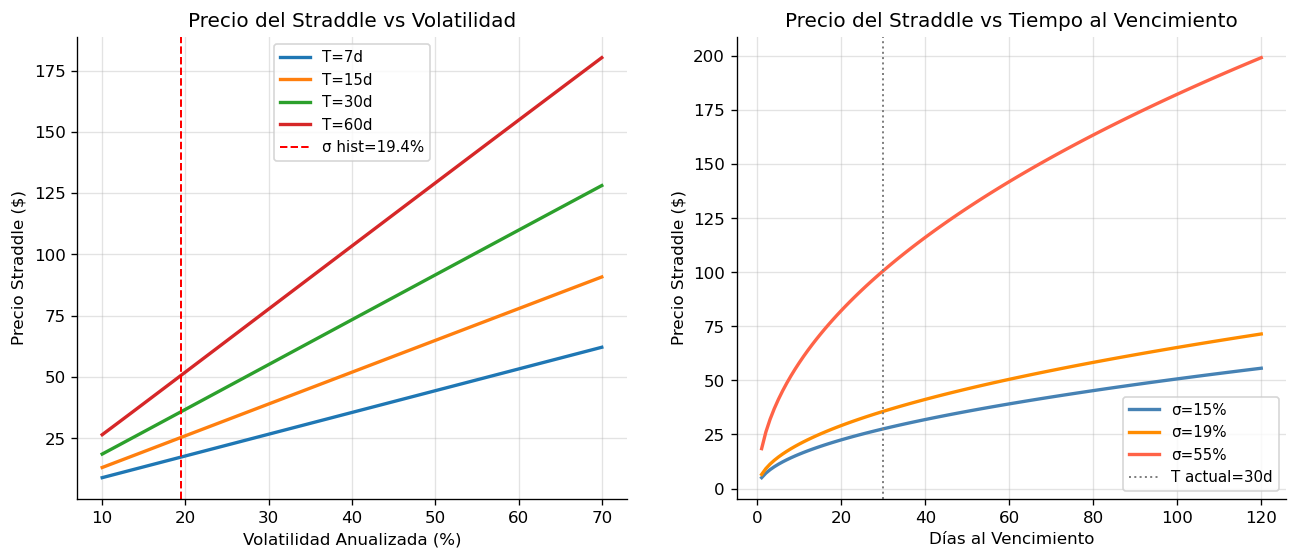

In [10]:
# Análisis de sensibilidad: precio del straddle vs volatilidad y tiempo al vencimiento
sigmas = np.linspace(0.10, 0.70, 50)
Ts     = [7/252, 15/252, 30/252, 60/252]  

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica 1: precio straddle vs volatilidad
for t_val in Ts:
    precios_vol = [bs_straddle(S0, K, r, s, t_val) for s in sigmas]
    label_dias = int(round(t_val * 252))
    axes[0].plot(sigmas*100, precios_vol, lw=2, label=f'T={label_dias}d')
axes[0].axvline(sigma*100, color='red', linestyle='--', lw=1.2, label=f'σ hist={sigma*100:.1f}%')
axes[0].set_title('Precio del Straddle vs Volatilidad', fontsize=12)
axes[0].set_xlabel('Volatilidad Anualizada (%)')
axes[0].set_ylabel('Precio Straddle ($)')
axes[0].legend(fontsize=9)

# Gráfica 2: precio straddle vs días al vencimiento
dias = np.arange(1, 121)
for sig_val, color in zip([0.15, sigma, 0.55], ['steelblue', 'darkorange', 'tomato']):
    precios_t = [bs_straddle(S0, K, r, sig_val, d/252) for d in dias]
    axes[1].plot(dias, precios_t, lw=2, color=color, label=f'σ={sig_val*100:.0f}%')
axes[1].axvline(T_DIAS, color='gray', linestyle=':', lw=1.2, label=f'T actual={T_DIAS}d')
axes[1].set_title('Precio del Straddle vs Tiempo al Vencimiento', fontsize=12)
axes[1].set_xlabel('Días al Vencimiento')
axes[1].set_ylabel('Precio Straddle ($)')
axes[1].legend(fontsize=9)



El análisis de sensibilidad de las gráficas confirma que el valor del Straddle depende de una carrera entre la volatilidad y el tiempo. En la primera gráfica, se observa una relación positiva y lineal con la volatilidad: a mayor incertidumbre, más cara es la estrategia, especialmente en contratos de largo plazo. Por otro lado, la segunda gráfica ilustra el decaimiento temporal, donde el precio erosiona de forma no lineal conforme se acerca el vencimiento; esta pérdida de valor es más agresiva en escenarios de alta volatilidad. Como hemos ido viendo a lo largo del proyecto, para que la estrategia sea rentable, el activo subyacente debe realizar un movimiento lo suficientemente violento como para compensar el costo diario del paso del tiempo y la prima pagada.

In [11]:
# Tabla Final
resumen = pd.DataFrame({
    'Parámetro': [
        'Precio Spot S₀', 'Strike K', 'Vencimiento (días)',
        'Vol. Histórica σ', 'Tasa libre r',
        'Prima Call (Mercado)', 'Prima Put (Mercado)', 'Costo Total',
        'Breakeven inferior', 'Breakeven superior',
        'Pérdida máxima', 'Ganancia potencial',
        'Precio MC',
        'Prob. de Ganancia (MC)', 'VaR 95% (MC)', 'CVaR 95% (MC)',
        'Delta (Δ)', 'Gamma (Γ)', 'Theta (Θ) /día', 'Vega (ν) /1%'
    ],
    'Valor': [
        f'${S0:.2f}', f'${K:.2f}', f'{T_DIAS} días hábiles',
        f'{sigma*100:.2f}%', f'{r*100:.2f}%',
        f'${C0:.4f}', f'${P0:.4f}', f'${costo_total:.4f}',
        f'${BE_inf:.4f}', f'${BE_sup:.4f}',
        f'-${costo_total:.4f}', 'Ilimitada (si S_T >> K o << K)',
        f'${precio_mc:.4f}',
        f'{prob_profit:.1f}%', f'${VaR_95:.4f}', f'${CVaR_95:.4f}',
        f'{delta_st:+.6f}', f'{gamma_st:.6f}',
        f'${theta_st:.6f}', f'${vega_st:.6f}'
    ]
})

print(resumen.to_string(index=False))

             Parámetro                          Valor
        Precio Spot S₀                        $667.74
              Strike K                        $668.00
    Vencimiento (días)                30 días hábiles
      Vol. Histórica σ                         19.43%
          Tasa libre r                          4.41%
  Prima Call (Mercado)                       $15.4500
   Prima Put (Mercado)                       $13.5800
           Costo Total                       $29.0300
    Breakeven inferior                      $638.9700
    Breakeven superior                      $697.0300
        Pérdida máxima                      -$29.0300
    Ganancia potencial Ilimitada (si S_T >> K o << K)
             Precio MC                       $42.1291
Prob. de Ganancia (MC)                          57.9%
          VaR 95% (MC)                      $-25.8305
         CVaR 95% (MC)                      $-27.4275
             Delta (Δ)                      +0.084440
             Gamma (Γ)      

En conjunto, los resultados muestran que el straddle requiere un movimiento de alrededor de ±4.4% para ser rentable, lo cual no es exagerado considerando la volatilidad reciente. La simulación sugiere que, en promedio, sí hay suficiente movimiento esperado para cubrir el costo, pero no de forma constante. El punto clave es que esta estrategia gana cuando el mercado se mueve más de lo normal y pierde cuando el precio se queda cerca del strike. Por eso, el mayor riesgo no es “equivocarse de dirección”, sino entrar en un periodo tranquilo donde la volatilidad baja y el tiempo va reduciendo el valor de la posición. En otras palabras, el éxito del trade depende menos del nivel actual del precio y más de si el mercado realmente se vuelve más activo en el corto plazo.

## <a name="discusion"></a>6. Discusión
Los resultados confirman que el Long Straddle sobre QQQ tiene una lógica financiera sólida para el contexto de abril de 2026, pero su rentabilidad no está garantizada. La diferencia entre el precio estimado por Monte Carlo y el teórico de Black-Scholes sugiere que el activo ha tendido históricamente a moverse más de lo que las primas anticipan, apuntando a una posible subvaluación relativa de las opciones. Sin embargo, este resultado es sensible al período de volatilidad elegido: si el mercado entra en un régimen de calma, la estimación resulta demasiado optimista. El volatility skew observado añade otro matiz importante: las puts más caras que las calls elevan el costo total del straddle más allá de lo que el modelo teórico indica, reduciendo el margen de ganancia efectivo.
Las principales limitaciones del estudio son tres: el supuesto de retornos normalmente distribuidos en la simulación subestima la probabilidad de movimientos extremos típicos de activos tecnológicos; la ausencia de costos de transacción sobreestima la rentabilidad real; y los resultados son sensibles a la ventana temporal usada para estimar la volatilidad histórica. Para investigaciones futuras, valdría explorar modelos de volatilidad estocástica que capturen el skew de forma endógena, evaluar estrategias de salida anticipada cuando sube la volatilidad implícita antes del vencimiento, e incorporar los costos de transacción en el cálculo del umbral de rentabilidad real.

## <a name="conclusiones"></a>7. Conclusiones

A lo largo del proyecto se construyó un análisis cuantitativo completo que permite evaluar la estrategia Long Straddle no como una apuesta sobre dirección, sino como una posición sobre la magnitud del movimiento. Los resultados convergen en un mensaje central: la rentabilidad depende de si el mercado se vuelve más activo de lo que el precio de las primas anticipaba al momento de entrada.
El ejercicio dejó tres aprendizajes fundamentales. Primero, el modelo de Black-Scholes es una herramienta útil de referencia, pero los precios de mercado divergen de forma sistemática porque el mercado incorpora una prima adicional por riesgo que el modelo no captura en su forma estándar. Segundo, el perfil griego del straddle (gamma y vega positivos, theta negativo) describe una posición que "compra tiempo y volatilidad": cuanto más tarde en materializarse el movimiento, más caro resulta mantenerla. Esto hace del monitoreo diario del theta una variable operativa tan relevante como el precio del subyacente. Tercero, la simulación Monte Carlo demostró que la estrategia tiene un sesgo favorable en promedio, pero con una distribución de resultados asimétricamente ancha: muchos escenarios de pérdida moderada coexisten con pocos escenarios de ganancia elevada (movimientos bruscos en cualquier dirección), lo que exige disciplina en la gestión de la posición; saber cuándo salir es tan importante como saber cuándo entrar.
En síntesis, el proyecto integró valuación teórica, análisis de mercado y simulación estocástica para demostrar que una estrategia aparentemente simple esconde una dinámica rica entre volatilidad, tiempo y riesgo de cola; comprenderla a este nivel es lo que distingue su uso informado de la mera especulación.


## <a name="biblio"></a>8. Bibliografías
- Black, F., & Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities.* Journal of Political Economy, 81(3), 637–654.
- Hull, J. C. (2022). *Options, Futures, and Other Derivatives* (11ª ed.). Pearson.
- Investopedia. (2024). Volatility smile. https://www.investopedia.com/terms/v/volatilitysmile.asp
- CME Group. (2023). Understanding implied volatility. https://www.cmegroup.com/education/courses/introduction-to-options/understanding-implied-volatility.html
- Boyle, P., Broadie, M., & Glasserman, P. (1997). Monte Carlo methods for security pricing. Journal of Economic Dynamics and Control, 21(8–9), 1267–1321.
- Natenberg, S. (1994). *Option Volatility and Pricing.* McGraw-Hill.
- Datos de mercado: Yahoo Finance via `yfinance` (2026).
- Invesco. (2026). *QQQ ETF Fact Sheet.* [https://www.invesco.com/qqq-etf/](https://www.invesco.com/qqq-etf/)